# BHNS GRB Classification

Classifying Black Hole Neutron Star mergers from the COMPAS fiducial population (Model A) using the [Gottlieb et al. (2023)](https://arxiv.org/abs/2309.00038) scheme with the [Foucart (2012)](https://arxiv.org/abs/1207.6304) NS tidal disruption formula.

**Classification rules (BHNS):**
- NS not disrupted outside ISCO → No GRB (NS plunges)
- Disrupted, disk mass `M_d < 0.1 M☉` → Short cbGRB
- Disrupted, disk mass `M_d ≥ 0.1 M☉` → Long cbGRB

BH spin `a` is not tracked by COMPAS - results are shown for `a = 0.0, 0.5, 0.7`.

**Data:** COMPAS fiducial BHNS simulation - [Zenodo 5178777](https://zenodo.org/records/5178777)

## 1. Load Data

M1 and M2 are reassigned using `stellarType` flags to ensure M_BH is always the black hole and M_NS is always the neutron star, regardless of which was the primary.

In [1]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt

path  = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5'
fdata = h5.File(path, 'r')
fDCO  = fdata['doubleCompactObjects']

M_BH           = fDCO['M1'][...].squeeze()
M_NS           = fDCO['M2'][...].squeeze()
weights        = fDCO['weight'][...].squeeze()
metallicity    = fDCO['Metallicity1'][...].squeeze()
mergesInHubble = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
tc             = fDCO['tc'][...].squeeze()
tform          = fDCO['tform'][...].squeeze()
m1zams         = fDCO['M1ZAMS'][...].squeeze()
m2zams         = fDCO['M2ZAMS'][...].squeeze()
stype1         = fDCO['stellarType1'][...].squeeze()
stype2         = fDCO['stellarType2'][...].squeeze()

# correct BH/NS assignment - BH=type 14, NS=type 13
# save originals before swapping to avoid overwrite bug
is_BH1 = (stype1 == 14)
M1_orig = M_BH.copy()
M2_orig = M_NS.copy()
M_BH    = np.where(is_BH1, M1_orig, M2_orig)
M_NS    = np.where(is_BH1, M2_orig, M1_orig)

mask_merging = (mergesInHubble == 1)
print(f"Total BHNS:             {len(M_BH):,}")
print(f"Merging in Hubble time: {mask_merging.sum():,}")
print(f"BH mass range: {M_BH[mask_merging].min():.1f} – {M_BH[mask_merging].max():.1f} M☉")
print(f"NS mass range: {M_NS[mask_merging].min():.2f} – {M_NS[mask_merging].max():.2f} M☉")

Total BHNS:             1,525,553
Merging in Hubble time: 1,525,553
BH mass range: 2.7 – 39.2 M☉
NS mass range: 1.26 – 2.50 M☉


## 2. Foucart Disk Mass & Disruption Check

Two corrections vs a naive Foucart (2012) application:
1. **Disruption pre-check:** Uses the Eggleton (1983) Roche lobe radius vs GR ISCO - only applies the fitting formula when the NS is actually disrupted outside the ISCO.
2. **Correct ISCO units:** `r̂_ISCO` is expressed in units of `G·M_total/c²` as required by the formula.

In [2]:
def r_isco(a_BH):
    """ISCO radius coefficient in units of G*M_BH/c^2 (Bardeen et al. 1972)."""
    Z1 = 1 + (1 - a_BH**2)**(1/3) * ((1 + a_BH)**(1/3) + (1 - a_BH)**(1/3))
    Z2 = np.sqrt(3*a_BH**2 + Z1**2)
    return 3 + Z2 - np.sign(a_BH + 1e-10) * np.sqrt((3 - Z1)*(3 + Z1 + 2*Z2))

def foucart_disk_mass(M_BH, M_NS, a_BH=0.0, R_NS_km=11.0):
    """
    Foucart (2012) remnant disk mass with physical disruption pre-check.

    Only applies the fitting formula when the NS is actually disrupted outside
    the ISCO (Roche lobe radius > ISCO radius). Returns 0 otherwise (NS plunges).

    Fixes vs naive implementation:
      - Disruption pre-check prevents unphysical large-Q extrapolation
      - r_ISCO is in units of G*M_total/c^2 as required by Foucart (2012)
    """
    G = 6.674e-11; c = 3e8; Msun = 1.989e30

    # --- Disruption pre-check (Eggleton 1983 Roche lobe vs ISCO) ---
    q_r      = M_NS / M_BH
    f_roche  = 0.49 * q_r**(2/3) / (0.6 * q_r**(2/3) + np.log(1 + q_r**(1/3)))
    r_tidal  = (R_NS_km * 1e3) / f_roche                   # tidal radius [m]
    r_ISCO   = r_isco(a_BH) * G * M_BH * Msun / c**2       # ISCO radius  [m]
    disrupted = r_tidal > r_ISCO

    # --- Foucart (2012) fitting formula ---
    C_NS  = G * M_NS * Msun / (R_NS_km * 1e3 * c**2)       # NS compactness
    eta   = M_NS * M_BH / (M_NS + M_BH)**2                  # symmetric mass ratio
    r_hat = r_isco(a_BH) * M_BH / (M_BH + M_NS)            # r_ISCO in units of G*M_total/c^2

    alpha, beta, gamma = 0.406, 0.139, 0.255
    M_rem_frac = alpha * (1 - 2*C_NS) / eta**(1/3) - beta * r_hat * C_NS + gamma
    M_disk = np.maximum(0.0, M_rem_frac) * M_NS

    return np.where(disrupted, M_disk, 0.0)

## 3. GRB Classification for Three BH Spin Values

In [3]:
BH  = M_BH[mask_merging]
NS  = M_NS[mask_merging]
w   = weights[mask_merging]

results = {}  # keyed by BH spin value
for a in [0.0, 0.5, 0.7]:
    M_disk    = foucart_disk_mass(BH, NS, a_BH=a)
    no_grb    = (M_disk == 0)
    short_grb = (M_disk > 0)  & (M_disk < 0.1)
    long_grb  = (M_disk >= 0.1)
    results[a] = (no_grb, short_grb, long_grb, M_disk)
    print(f"a={a}: No GRB={no_grb.sum():,} ({100*no_grb.mean():.1f}%)  "
          f"Short={short_grb.sum():,} ({100*short_grb.mean():.1f}%)  "
          f"Long={long_grb.sum():,} ({100*long_grb.mean():.1f}%)")

a=0.0: No GRB=1,509,125 (98.9%)  Short=0 (0.0%)  Long=16,428 (1.1%)
a=0.5: No GRB=1,413,206 (92.6%)  Short=0 (0.0%)  Long=112,347 (7.4%)
a=0.7: No GRB=1,183,313 (77.6%)  Short=0 (0.0%)  Long=342,240 (22.4%)


## 4. M_BH vs M_NS Mass Plane

Each panel shows the mass plane for a different assumed BH spin. Orange = long cbGRB (NS disrupted, massive disk); gray = no GRB (NS plunges).

/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_54742/211885907.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_54742/211885907.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('/Users/josephrodriguez/research visualization/plots/bhns_mass_plane_spin.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/envs/grb-env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


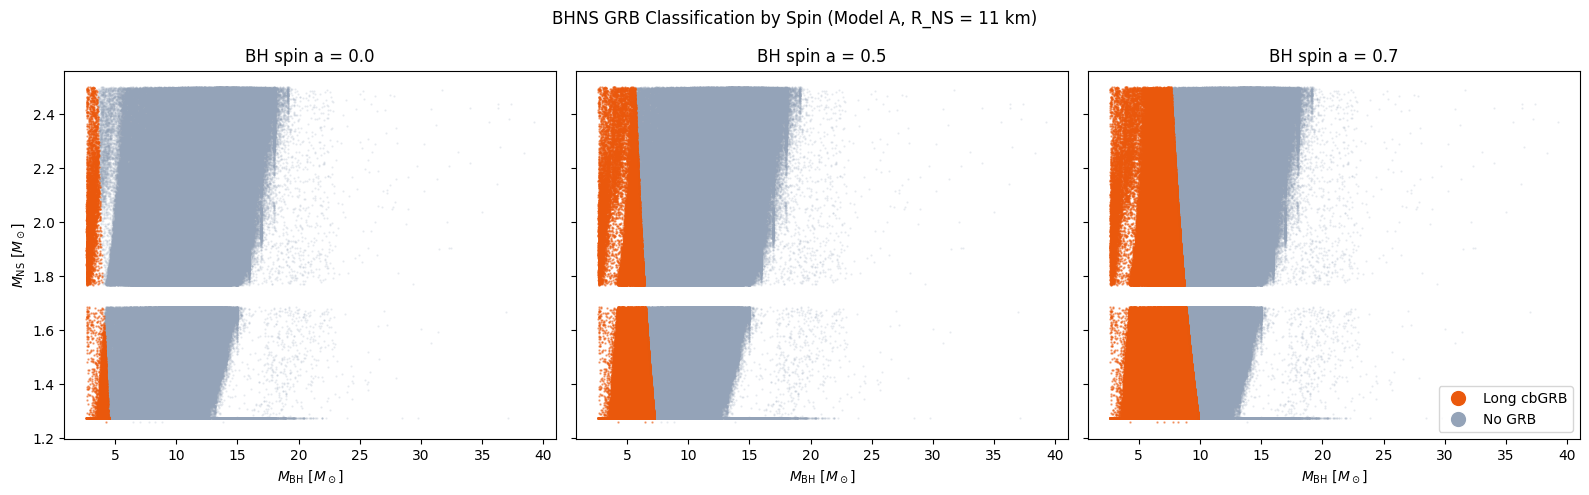

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
spins = [0.0, 0.5, 0.7]

BH = M_BH[mask_merging]
NS = M_NS[mask_merging]

for ax, a in zip(axes, spins):
    no_grb, short_grb, long_grb, M_disk = results[a]
    ax.scatter(BH[no_grb],   NS[no_grb],   s=0.3, alpha=0.2, color='#94A3B8',       rasterized=True)
    ax.scatter(BH[long_grb], NS[long_grb], s=0.5, alpha=0.5, color='#EA580C',  rasterized=True)
    ax.set_xlabel(r'$M_\mathrm{BH}$ [$M_\odot$]')
    ax.set_title(f'BH spin a = {a}')

axes[0].set_ylabel(r'$M_\mathrm{NS}$ [$M_\odot$]')

from matplotlib.lines import Line2D
legend = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#EA580C', label='Long cbGRB'),
          Line2D([0],[0], marker='o', color='w', markerfacecolor='#94A3B8',       label='No GRB')]
axes[2].legend(handles=legend, markerscale=2)
plt.suptitle('BHNS GRB Classification by Spin (Model A, R_NS = 11 km)')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bhns_mass_plane_spin.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Formation Efficiency vs Metallicity

Fiducial spin `a = 0.5`. Formation efficiency = mergers per solar mass of star-forming material.

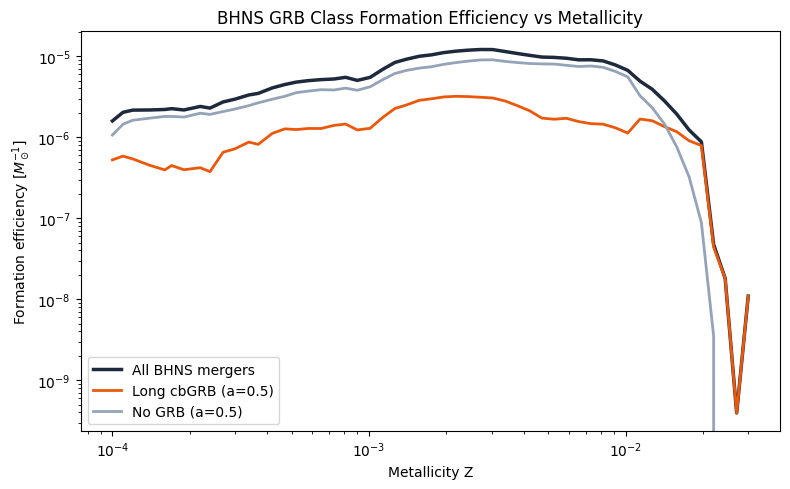

In [5]:
metallicityGrid = [0.0001, 0.00011, 0.00012, 0.00014, 0.00016, 0.00017,
                   0.00019, 0.00022, 0.00024, 0.00027, 0.0003,  0.00034,
                   0.00037, 0.00042, 0.00047, 0.00052, 0.00058, 0.00065,
                   0.00073, 0.00081, 0.0009,  0.00101, 0.00113, 0.00126,
                   0.0014,  0.00157, 0.00175, 0.00195, 0.00218, 0.00243,
                   0.00272, 0.00303, 0.00339, 0.00378, 0.00422, 0.00471,
                   0.00526, 0.00587, 0.00655, 0.00732, 0.00817, 0.00912,
                   0.01018, 0.01137, 0.01269, 0.01416, 0.01581, 0.01765,
                   0.01971, 0.022,   0.0244,  0.02705, 0.03]

meanMassEvolved = 77708655

Z_all   = metallicity[mask_merging]
w_all   = weights[mask_merging]
unique_Z = np.unique(metallicity)

# use a=0.5 as the fiducial spin (middle case)
_, _, long_fid, disk_fid = results[0.5]
no_fid = ~long_fid

eff_total = np.zeros(len(metallicityGrid))
eff_long  = np.zeros(len(metallicityGrid))
eff_nogrb = np.zeros(len(metallicityGrid))

for i, Z in enumerate(metallicityGrid):
    if Z in unique_Z:
        maskZ = (Z_all == Z)
        eff_total[i] = np.sum(w_all[maskZ])                  / meanMassEvolved
        eff_long[i]  = np.sum(w_all[maskZ & long_fid])       / meanMassEvolved
        eff_nogrb[i] = np.sum(w_all[maskZ & no_fid])         / meanMassEvolved

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(metallicityGrid, eff_total, color='#1E293B',      lw=2.5, label='All BHNS mergers')
ax.plot(metallicityGrid, eff_long,  color='#EA580C', lw=2,   label='Long cbGRB (a=0.5)')
ax.plot(metallicityGrid, eff_nogrb, color='#94A3B8',       lw=2,   label='No GRB (a=0.5)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Metallicity Z')
ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$')
ax.set_title('BHNS GRB Class Formation Efficiency vs Metallicity')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bhns_formation_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

### Spin Sensitivity on Long cbGRB Efficiency

BH spin is the dominant factor controlling whether a BHNS merger produces a GRB at all.

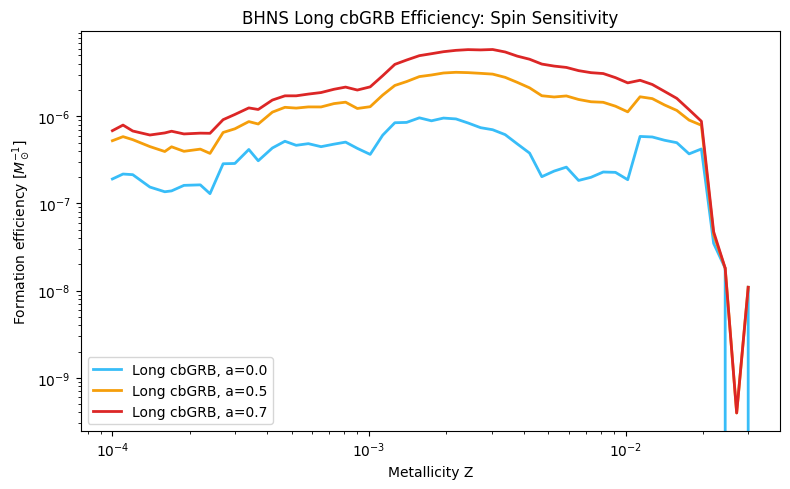

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {0.0: '#38BDF8', 0.5: '#F59E0B', 0.7: '#DC2626'}

for a in [0.0, 0.5, 0.7]:
    _, _, long_a, _ = results[a]
    eff_a = np.zeros(len(metallicityGrid))
    for i, Z in enumerate(metallicityGrid):
        if Z in unique_Z:
            maskZ = (Z_all == Z)
            eff_a[i] = np.sum(w_all[maskZ & long_a]) / meanMassEvolved
    ax.plot(metallicityGrid, eff_a, color=colors[a], lw=2, label=f'Long cbGRB, a={a}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Metallicity Z')
ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$')
ax.set_title('BHNS Long cbGRB Efficiency: Spin Sensitivity')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bhns_spin_efficiency_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. EOS Sensitivity

A more compact NS (smaller `R_NS`, softer EOS) is harder to disrupt. Vary `R_NS` from 9–13 km at `a = 0`.

a=0.5, R_NS=9 km:  Long=2.4%  Short=0.0%  No GRB=97.6%
a=0.5, R_NS=10 km:  Long=4.4%  Short=0.0%  No GRB=95.6%
a=0.5, R_NS=11 km:  Long=7.4%  Short=0.0%  No GRB=92.6%
a=0.5, R_NS=12 km:  Long=11.6%  Short=0.0%  No GRB=88.4%
a=0.5, R_NS=13 km:  Long=17.4%  Short=0.0%  No GRB=82.6%
a=0.7, R_NS=9 km:  Long=8.2%  Short=0.0%  No GRB=91.8%
a=0.7, R_NS=10 km:  Long=14.1%  Short=0.0%  No GRB=85.9%
a=0.7, R_NS=11 km:  Long=22.4%  Short=0.0%  No GRB=77.6%
a=0.7, R_NS=12 km:  Long=33.0%  Short=0.0%  No GRB=67.0%
a=0.7, R_NS=13 km:  Long=44.6%  Short=0.0%  No GRB=55.4%


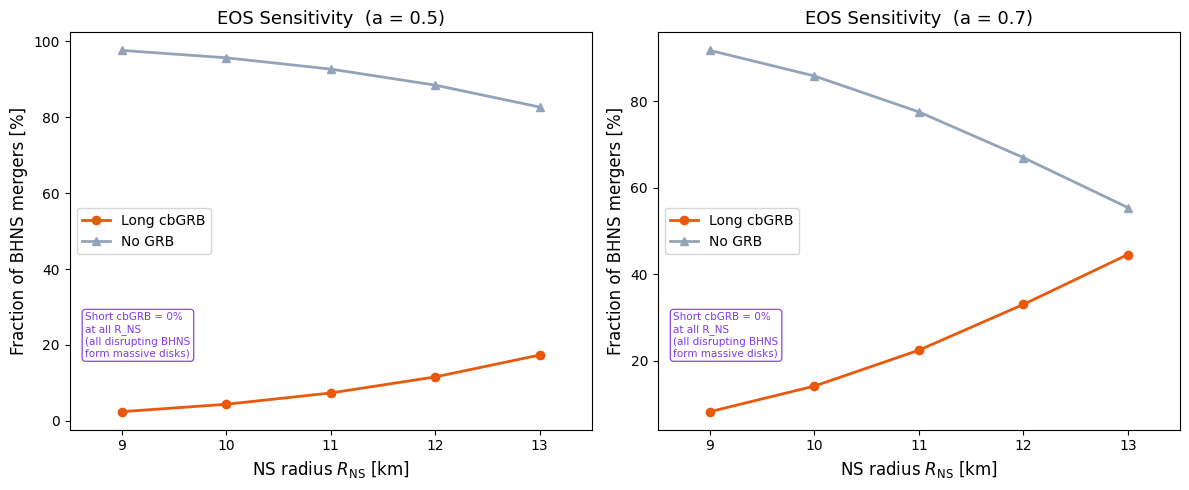

In [7]:
R_NS_range = [9, 10, 11, 12, 13]   # km

# Run at a=0.5 and a=0.7 — the regime where disruption actually occurs
spin_panels = {0.5: {'color': '#F59E0B', 'label': 'a = 0.5'},
               0.7: {'color': '#DC2626', 'label': 'a = 0.7'}}
results_RNS = {}

for a_spin in [0.5, 0.7]:
    frac_long, frac_short, frac_nogrb = [], [], []
    for R in R_NS_range:
        M_disk   = foucart_disk_mass(BH, NS, a_BH=a_spin, R_NS_km=R)
        no_grb   = (M_disk == 0)
        long_grb = (M_disk >= 0.1)
        short_grb = (M_disk > 0) & (M_disk < 0.1)
        frac_long.append(100 * long_grb.mean())
        frac_short.append(100 * short_grb.mean())
        frac_nogrb.append(100 * no_grb.mean())
        print(f'a={a_spin}, R_NS={R} km:  '
              f'Long={100*long_grb.mean():.1f}%  '
              f'Short={100*short_grb.mean():.1f}%  '
              f'No GRB={100*no_grb.mean():.1f}%')
    results_RNS[a_spin] = dict(long=frac_long, short=frac_short, nogrb=frac_nogrb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, a_spin in zip(axes, [0.5, 0.7]):
    d = results_RNS[a_spin]
    ax.plot(R_NS_range, d['long'],  color='#EA580C', lw=2, marker='o', label='Long cbGRB')
    ax.plot(R_NS_range, d['nogrb'], color='#94A3B8', lw=2, marker='^', label='No GRB')
    # Short cbGRB is identically 0% at a>=0.5: all disrupting systems form massive disks
    ax.text(0.03, 0.18, 'Short cbGRB = 0%\nat all R_NS\n(all disrupting BHNS\nform massive disks)',
            transform=ax.transAxes, fontsize=7.5, color='#7C3AED',
            ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#7C3AED', alpha=0.85))
    ax.set_xlim(8.5, 13.5)
    ax.set_xlabel(r'NS radius $R_\mathrm{NS}$ [km]', fontsize=12)
    ax.set_ylabel('Fraction of BHNS mergers [%]', fontsize=12)
    ax.set_title(f'EOS Sensitivity  (a = {a_spin})', fontsize=13)
    ax.legend(fontsize=10, loc='center left')
    ax.set_xticks(R_NS_range)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bhns_eos_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 7. Delay Time Distribution

Total delay time = stellar evolution time + coalescence time.
Shown for the fiducial spin `a = 0.5`; split by GRB class.

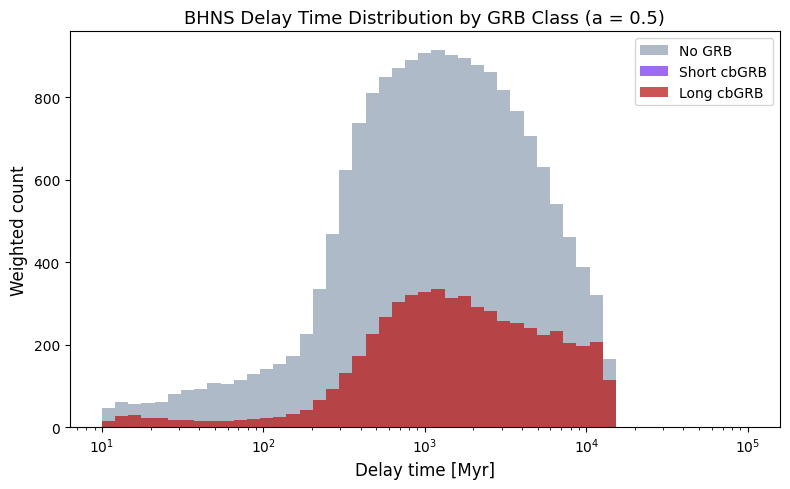

In [8]:
delay_BHNS_all = (tform + tc)[mask_merging]
no_grb_05, short_grb_05, long_grb_05, _ = results[0.5]
w_m = weights[mask_merging]

bins = np.logspace(1, 5, 50)   # 10 Myr to 100 Gyr

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(delay_BHNS_all[no_grb_05],    bins=bins, weights=w_m[no_grb_05],
        color='#94A3B8', alpha=0.75, label='No GRB')
ax.hist(delay_BHNS_all[short_grb_05], bins=bins, weights=w_m[short_grb_05],
        color='#7C3AED', alpha=0.75, label='Short cbGRB')
ax.hist(delay_BHNS_all[long_grb_05],  bins=bins, weights=w_m[long_grb_05],
        color='#B91C1C', alpha=0.75, label='Long cbGRB')
ax.set_xscale('log')
ax.set_xlabel('Delay time [Myr]', fontsize=12)
ax.set_ylabel('Weighted count', fontsize=12)
ax.set_title('BHNS Delay Time Distribution by GRB Class (a = 0.5)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_delay_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Export

Save formation efficiency arrays for use in the comparison notebook.

In [9]:
import numpy as np

np.save('/Users/josephrodriguez/research visualization/results/eff_BHNS.npy',
        np.array([eff_total, eff_long]))   # eff_long = a=0.5 fiducial
print("BHNS efficiencies saved.")

BHNS efficiencies saved.
